In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import RFECV
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve

In [4]:
df = pd.read_csv("data/archive/AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df = df.dropna(subset=["reviews_per_month"])
X = df.drop(columns=["reviews_per_month"])
y = df["reviews_per_month"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123
)


In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,3.884300e+04,3.884300e+04,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000
mean,1.809646e+07,6.423915e+07,40.728134,-73.951148,142.317947,5.868059,29.297557,1.373221,5.164457,114.882888
std,1.069370e+07,7.588847e+07,0.054990,0.046695,196.945624,17.384784,48.186374,1.680442,26.295665,129.543636
min,2.539000e+03,2.438000e+03,40.506410,-74.244420,0.000000,1.000000,1.000000,0.010000,1.000000,0.000000
25%,8.720027e+06,7.033824e+06,40.688640,-73.982470,69.000000,1.000000,3.000000,0.190000,1.000000,0.000000
50%,1.887146e+07,2.837193e+07,40.721710,-73.954800,101.000000,2.000000,9.000000,0.720000,1.000000,55.000000
75%,2.755482e+07,1.018465e+08,40.762990,-73.935020,170.000000,4.000000,33.000000,2.020000,2.000000,229.000000
max,3.645581e+07,2.738417e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
df.isna().sum()

id                                 0
name                               6
host_id                            0
host_name                         16
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                        0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
dtype: int64

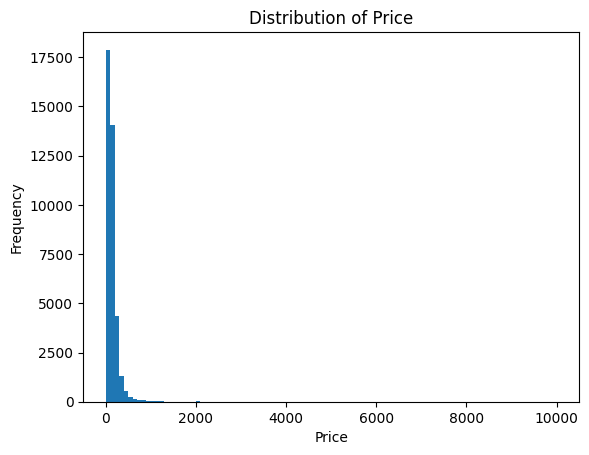

In [8]:
plt.figure()
plt.hist(df["price"], bins=100)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

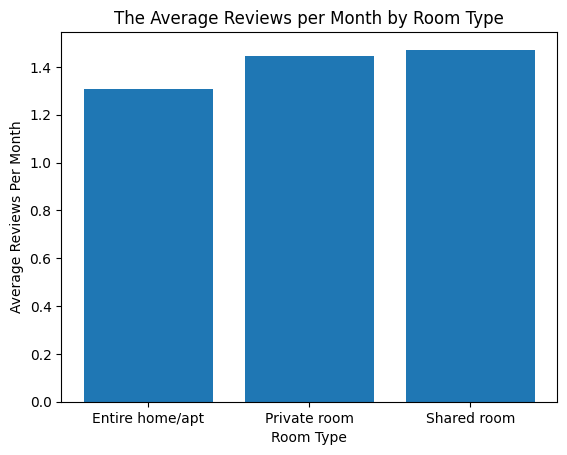

In [9]:
df_temp = df.dropna(subset=["reviews_per_month"])
room_reviews = df_temp.groupby("room_type")["reviews_per_month"].mean()
plt.figure()
plt.bar(room_reviews.index, room_reviews.values)
plt.title("The Average Reviews per Month by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Reviews Per Month")
plt.show()

In [10]:
df["price_per_minimum_night"] = df["price"] / df["minimum_nights"]
df['total_expected_reviews'] = df['availability_365'] / df['minimum_nights']
df['centrality'] = (40.7589 - df['latitude']).abs() + ( -73.9851 - df['longitude']).abs()
df['host_experience'] = df['calculated_host_listings_count'] * df['availability_365'] / 365
df['price_per_review'] = df['price'] / (df['number_of_reviews'] + 1)

In [11]:
X = df.drop(columns=["reviews_per_month","price","price_per_minimum_night"])
y = df["reviews_per_month"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123
)

In [12]:
numeric_features = [
    "minimum_nights",
    "number_of_reviews",
    "availability_365",
    "latitude",
    "longitude",
    "total_expected_reviews",
    "centrality",
    "host_experience",
    "price_per_review"
]
categorical_features = [
    "neighbourhood_group",
    "room_type"
]
numeric_features, categorical_features

(['minimum_nights',
  'number_of_reviews',
  'availability_365',
  'latitude',
  'longitude',
  'total_expected_reviews',
  'centrality',
  'host_experience',
  'price_per_review'],
 ['neighbourhood_group', 'room_type'])

In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
numeric_transformer

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
categorical_transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [ ]:
# this is the baseline model
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("Baseline:", mae)

Baseline: 1.2558884715801322


In [15]:
# training linear model
pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge())
])

param_grid = {"model__alpha": [0.01, 0.1, 1, 10, 100]}

search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best alpha:", search.best_params_["model__alpha"])
print("Best CV MAE:", -search.best_score_)

Best alpha: 10
Best CV MAE: 0.8841021183346882


In [16]:
best_model = search.best_estimator_

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

print("CV MAE mean:", -cv_scores.mean())
print("CV MAE std:", (-cv_scores).std())
print("Individual fold MAE:", -cv_scores)

CV MAE mean: 0.8841021183346882
CV MAE std: 0.0060241664128367935
Individual fold MAE: [0.88436715 0.88151596 0.87907319 0.89559995 0.87995434]


In [17]:
models = {
    "KNN": KNeighborsRegressor(),
    "RandomForest": RandomForestRegressor(random_state=123, n_estimators=200),
    "GradientBoosting": GradientBoostingRegressor(random_state=123)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
        return_train_score=True,
        n_jobs=-1
    )
    
    results.append({
        "model": name,
        "train_MAE_mean": (-cv_out["train_score"]).mean(),
        "test_MAE_mean": (-cv_out["test_score"]).mean(),
        "fit_time_mean": cv_out["fit_time"].mean(),
        "score_time_mean": cv_out["score_time"].mean()
    })

results_df = pd.DataFrame(results).sort_values("test_MAE_mean")
results_df

,model,train_MAE_mean,test_MAE_mean,fit_time_mean,score_time_mean
1,RandomForest,0.258908,0.701437,16.502666,0.465446
2,GradientBoosting,0.693805,0.710240,2.965540,0.008654
0,KNN,0.623456,0.770845,0.031247,0.278528


In [18]:
selector = RFECV(
    estimator=Ridge(alpha=search.best_params_["model__alpha"]),
    step=1,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

fs_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("feature_selection", selector),
    ("model", Ridge(alpha=search.best_params_["model__alpha"]))
])

cv_scores_fs = cross_validate(
    fs_pipe,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
    n_jobs=-1
)

print("Feature Selection CV MAE mean:", (-cv_scores_fs["test_score"]).mean())
print("Feature Selection CV MAE std:", (-cv_scores_fs["test_score"]).std())

Feature Selection CV MAE mean: 0.8839880246957075
Feature Selection CV MAE std: 0.0059809980752871545


In [20]:
tuned_results = []

for name, model in models.items():
    print(f"\nTuning {name}...")
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    param_distributions = {}
    
    if name == "KNN":
        param_distributions = {
            "model__n_neighbors": [5, 10, 15, 20, 30],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    elif name == "RandomForest":
        param_distributions = {
            "model__n_estimators": [200, 400, 600],
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", 0.5]
        }
    elif name == "GradientBoosting":
        param_distributions = {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.1, 0.2],
            "model__max_depth": [3, 5, 7],
            "model__min_samples_split": [2, 5, 10],
            "model__subsample": [0.8, 0.9, 1.0]
        }
    
    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_distributions,
        n_iter=20 if name != "KNN" else 15,
        cv=5,
        scoring="neg_mean_absolute_error",
        random_state=123,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    
    tuned_results.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_mae": -search.best_score_,
        "untuned_mae": 0.701361 if name == "RandomForest" else 
                     0.710240 if name == "GradientBoosting" else 0.770845
    })
    
    print(f"Best {name} params: {search.best_params_}")
    print(f"Best {name} CV MAE: {-search.best_score_:.3f}")

tuned_df = pd.DataFrame(tuned_results)
print("\n=== TUNED RESULTS ===")
print(tuned_df[["model", "untuned_mae", "cv_mae"]].round(3))



Tuning KNN...
Best KNN params: {'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 15}
Best KNN CV MAE: 0.728

Tuning RandomForest...


/Users/leowu555/miniforge3/envs/cpsc330/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RandomForest params: {'model__n_estimators': 600, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best RandomForest CV MAE: 0.684

Tuning GradientBoosting...
Best GradientBoosting params: {'model__subsample': 0.9, 'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__max_depth': 7, 'model__learning_rate': 0.1}
Best GradientBoosting CV MAE: 0.694

=== TUNED RESULTS ===
              model  untuned_mae  cv_mae
0               KNN        0.771   0.728
1      RandomForest        0.701   0.684
2  GradientBoosting        0.710   0.694


In [21]:
rf_tuned = tuned_results[1]
rf_pipe_tuned = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=rf_tuned["best_params"]["model__n_estimators"],
        max_depth=rf_tuned["best_params"]["model__max_depth"],
        min_samples_split=rf_tuned["best_params"]["model__min_samples_split"],
        min_samples_leaf=rf_tuned["best_params"]["model__min_samples_leaf"],
        max_features=rf_tuned["best_params"]["model__max_features"],
        random_state=123
    ))
])

rf_pipe_tuned.fit(X_train, y_train)

rf_model = rf_pipe_tuned.named_steps["model"]
importances = rf_model.feature_importances_

feature_names = rf_pipe_tuned.named_steps["preprocess"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 10 Most Important Features:")
print(importance_df.head(10).round(4))

Top 10 Most Important Features:
                           feature  importance
1           num__number_of_reviews      0.2305
8            num__price_per_review      0.1831
5      num__total_expected_reviews      0.1144
2            num__availability_365      0.0890
7             num__host_experience      0.0852
0              num__minimum_nights      0.0809
6                  num__centrality      0.0663
4                   num__longitude      0.0652
3                    num__latitude      0.0560
14  cat__room_type_Entire home/apt      0.0079


<Figure size 1000x600 with 0 Axes>

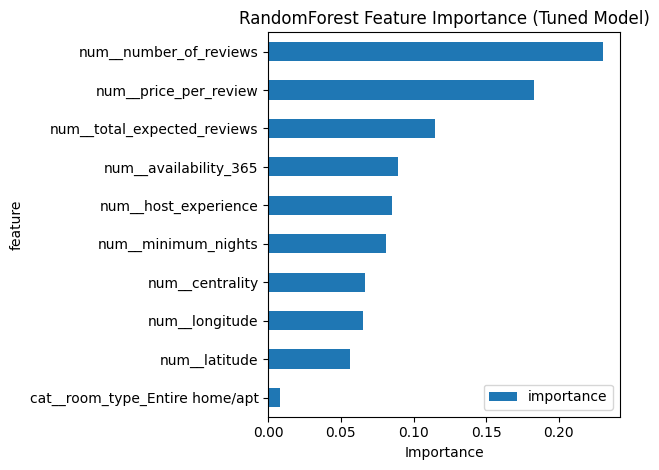

In [22]:
plt.figure(figsize=(10, 6))
importance_df.head(10).plot(kind="barh", x="feature", y="importance")
plt.title("RandomForest Feature Importance (Tuned Model)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

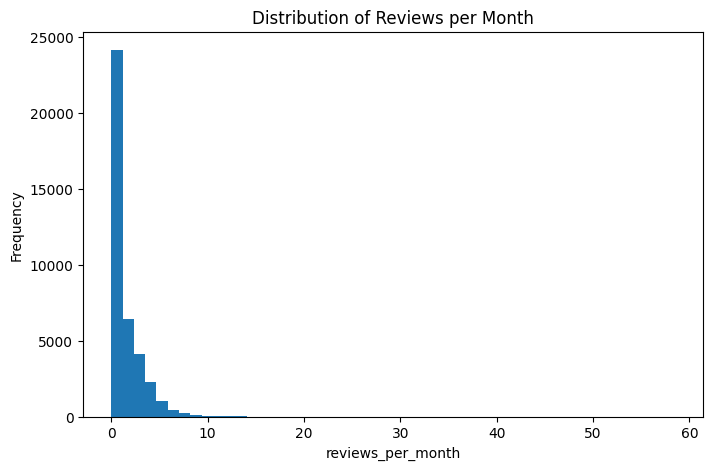

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(df["reviews_per_month"], bins=50)
plt.title("Distribution of Reviews per Month")
plt.xlabel("reviews_per_month")
plt.ylabel("Frequency")
plt.show()

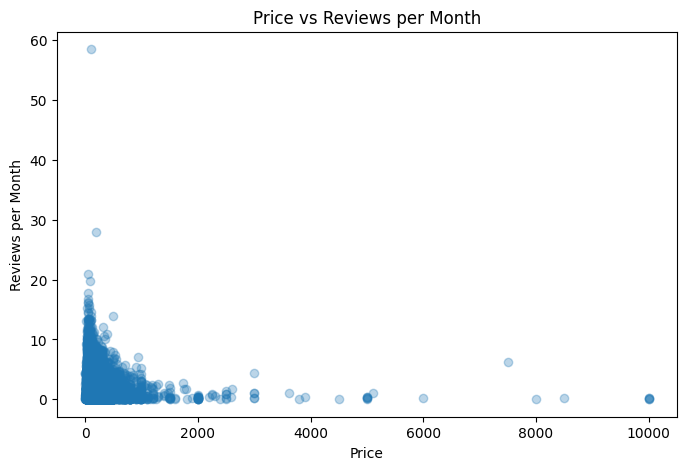

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(df["price"], df["reviews_per_month"], alpha=0.3)
plt.title("Price vs Reviews per Month")
plt.xlabel("Price")
plt.ylabel("Reviews per Month")
plt.show()

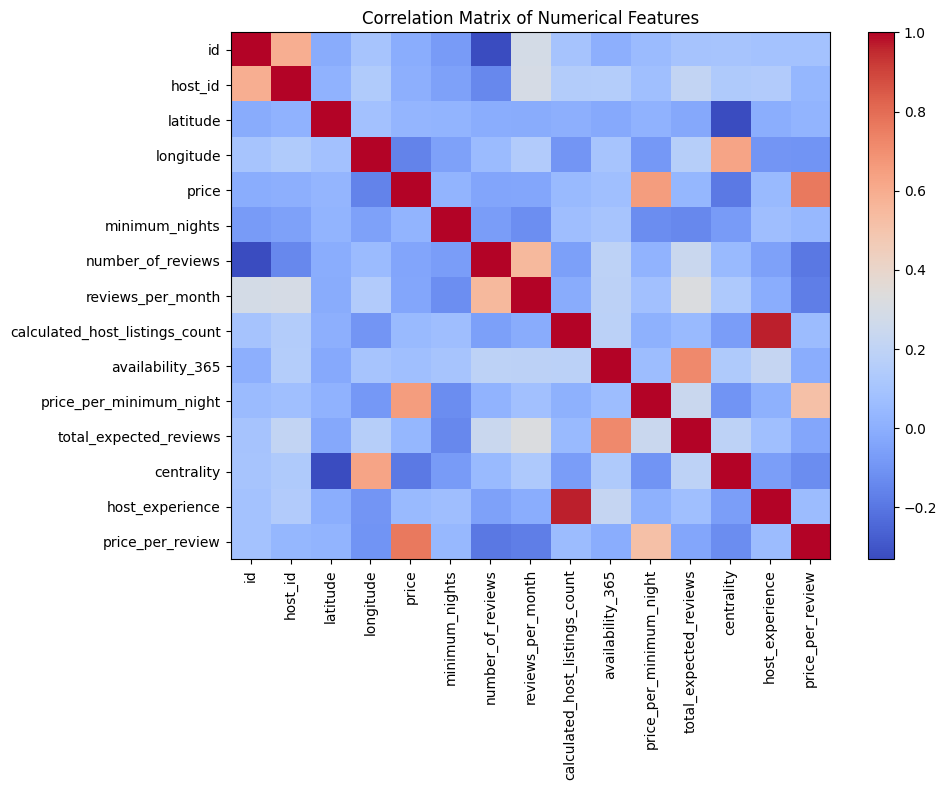

In [30]:
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

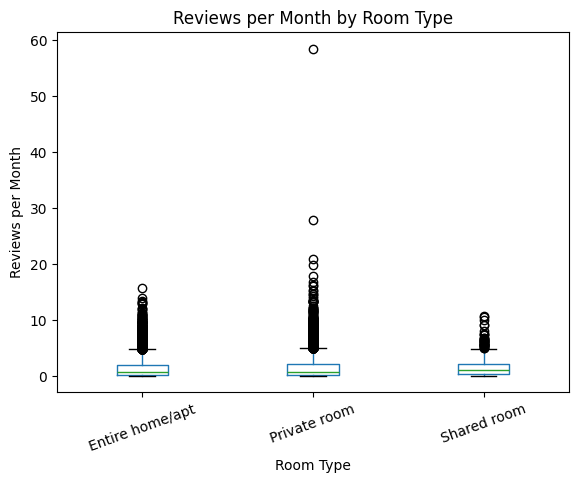

In [31]:
plt.figure(figsize=(8, 5))
df.boxplot(column="reviews_per_month", by="room_type", grid=False)
plt.title("Reviews per Month by Room Type")
plt.suptitle("")
plt.xlabel("Room Type")
plt.ylabel("Reviews per Month")
plt.xticks(rotation=20)
plt.show()

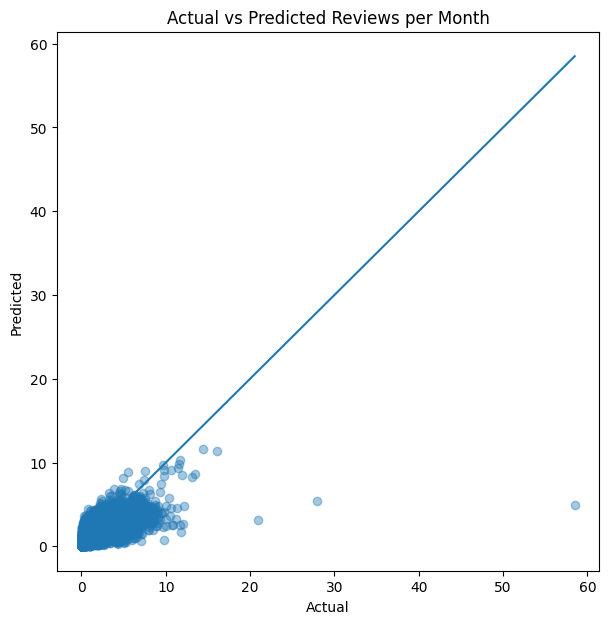

In [32]:
y_test_pred = rf_pipe_tuned.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_test_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Actual vs Predicted Reviews per Month")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

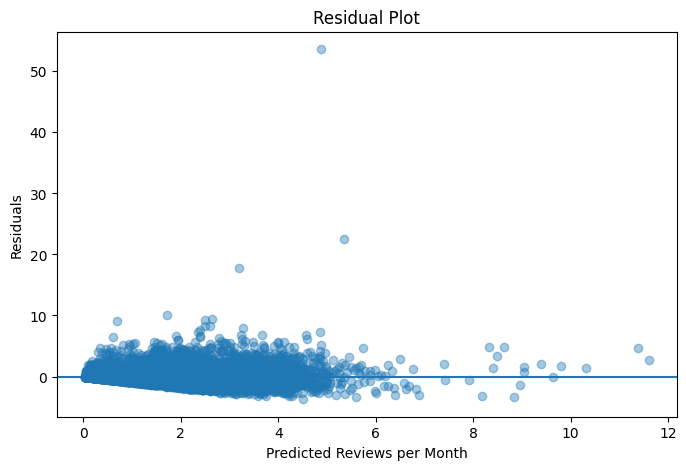

In [33]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.4)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.xlabel("Predicted Reviews per Month")
plt.ylabel("Residuals")
plt.show()

In [23]:
y_test_pred = rf_pipe_tuned.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"RandomForest Test MAE: {test_mae:.3f}")
print(f"RandomForest CV MAE:   {rf_tuned['cv_mae']:.3f}")
print(f"Gap:                   {test_mae - rf_tuned['cv_mae']:.3f}")

RandomForest Test MAE: 0.693
RandomForest CV MAE:   0.684
Gap:                   0.009


In [24]:
ridge_test_pred = search.best_estimator_.predict(X_test)
ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)
print(f"Ridge Test MAE: {ridge_test_mae:.3f} (vs CV 0.884)")

Ridge Test MAE: 0.697 (vs CV 0.884)


In [25]:
idx = 1
sample = X_test.iloc[[idx]]
pred = rf_pipe_tuned.predict(sample)[0]
actual = y_test.iloc[idx]

print(f"Sample {idx}: Pred={pred:.2f}, Actual={actual:.2f}, Error={abs(pred-actual):.2f}")

preprocessed = rf_pipe_tuned.named_steps["preprocess"].transform(sample)
contributions = rf_model.feature_importances_ * preprocessed[0]
top_contrib = pd.DataFrame({
    "feature": feature_names,
    "contribution": contributions
}).sort_values("contribution", key=abs, ascending=False).head(5)

print("Top 5 feature contributions:")
print(top_contrib.round(3))

Sample 1: Pred=0.06, Actual=0.02, Error=0.04
Top 5 feature contributions:
                       feature  contribution
1       num__number_of_reviews        -0.135
6              num__centrality        -0.084
2        num__availability_365        -0.079
5  num__total_expected_reviews        -0.073
8        num__price_per_review         0.030


In [26]:
idx = 2
sample = X_test.iloc[[idx]]
pred = rf_pipe_tuned.predict(sample)[0]
actual = y_test.iloc[idx]

print(f"Sample {idx}: Pred={pred:.2f}, Actual={actual:.2f}, Error={abs(pred-actual):.2f}")

preprocessed = rf_pipe_tuned.named_steps["preprocess"].transform(sample)
contributions = rf_model.feature_importances_ * preprocessed[0]
top_contrib = pd.DataFrame({
    "feature": feature_names,
    "contribution": contributions
}).sort_values("contribution", key=abs, ascending=False).head(5)

print("Top 5 feature contributions:")
print(top_contrib.round(3))

Sample 2: Pred=0.50, Actual=0.21, Error=0.29
Top 5 feature contributions:
                       feature  contribution
2        num__availability_365        -0.079
5  num__total_expected_reviews        -0.073
1       num__number_of_reviews        -0.055
4               num__longitude        -0.048
3                num__latitude        -0.043


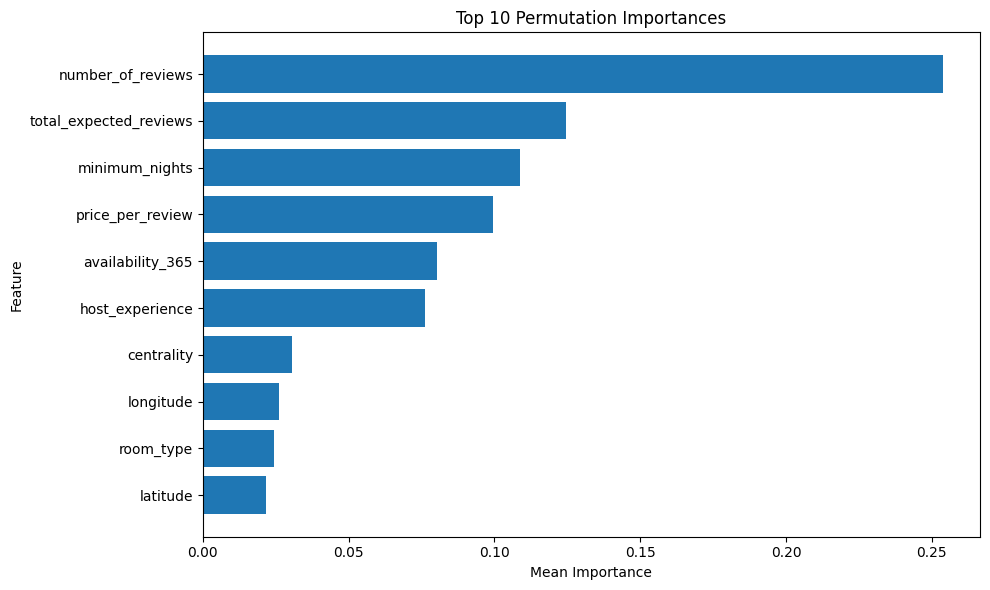

,feature,importance
10,number_of_reviews,0.253814
14,total_expected_reviews,0.124564
9,minimum_nights,0.108655
17,price_per_review,0.099455
13,availability_365,0.080182
16,host_experience,0.076060
15,centrality,0.030655
7,longitude,0.026233
8,room_type,0.024478
6,latitude,0.021678


In [35]:
perm_result = permutation_importance(
    rf_pipe_tuned,
    X_test,
    y_test,
    n_repeats=10,
    random_state=123,
    scoring="neg_mean_absolute_error"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_result.importances_mean
}).sort_values("importance", ascending=False)

perm_top = perm_df.head(10).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(perm_top["feature"], perm_top["importance"])
plt.title("Top 10 Permutation Importances")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

perm_df.head(10)

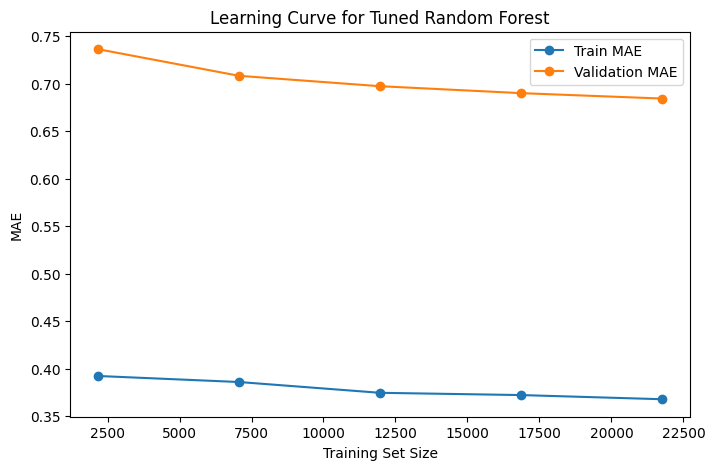

In [38]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_pipe_tuned,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mae = -train_scores.mean(axis=1)
val_mae = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mae, marker="o", label="Train MAE")
plt.plot(train_sizes, val_mae, marker="o", label="Validation MAE")
plt.title("Learning Curve for Tuned Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("MAE")
plt.legend()
plt.show()

In [39]:
summary_df = pd.DataFrame([
    {"Model": "DummyRegressor (mean)", "CV MAE": None, "Test MAE": 1.2559, "Notes": "Baseline predicting mean"},
    {"Model": "Ridge (tuned alpha=10)", "CV MAE": 0.8841, "Test MAE": None, "Notes": "Linear model"},
    {"Model": "KNN (untuned)", "CV MAE": 0.7708, "Test MAE": None, "Notes": "Slow scoring, weaker performance"},
    {"Model": "GradientBoosting (untuned)", "CV MAE": 0.7102, "Test MAE": None, "Notes": "Good generalization, fast scoring"},
    {"Model": "RandomForest (untuned)", "CV MAE": 0.7014, "Test MAE": None, "Notes": "Best of untuned non-linear models"},
    {"Model": "KNN (tuned)", "CV MAE": 0.7280, "Test MAE": None, "Notes": "Improved with distance weighting + p=1"},
    {"Model": "GradientBoosting (tuned)", "CV MAE": 0.6950, "Test MAE": None, "Notes": "Slight improvement after tuning"},
    {"Model": "RandomForest (tuned)", "CV MAE": 0.6840, "Test MAE": 0.6930, "Notes": "Best overall model"}
])

summary_df

,Model,CV MAE,Test MAE,Notes
0,DummyRegressor (mean),NaN,1.2559,Baseline predicting mean
1,Ridge (tuned alpha=10),0.8841,NaN,Linear model
2,KNN (untuned),0.7708,NaN,"Slow scoring, weaker performance"
3,GradientBoosting (untuned),0.7102,NaN,"Good generalization, fast scoring"
4,RandomForest (untuned),0.7014,NaN,Best of untuned non-linear models
5,KNN (tuned),0.7280,NaN,Improved with distance weighting + p=1
6,GradientBoosting (tuned),0.6950,NaN,Slight improvement after tuning
7,RandomForest (tuned),0.6840,0.6930,Best overall model


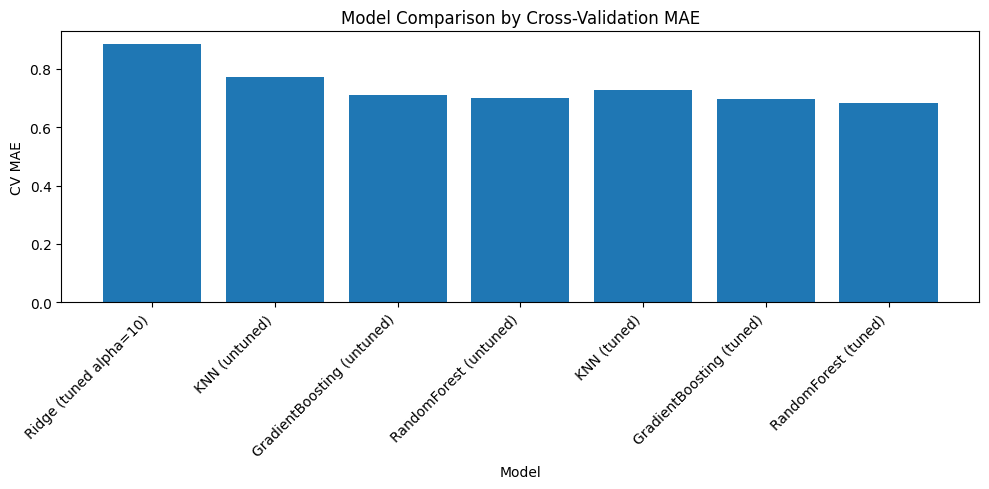

In [40]:
plot_df = summary_df.dropna(subset=["CV MAE"])

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["CV MAE"])
plt.title("Model Comparison by Cross-Validation MAE")
plt.xlabel("Model")
plt.ylabel("CV MAE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# insights: Since there were both numerical and categorical variables, it was important for model performance to use a preprocessing pipeline with scaling and one-hot encoding. The poor performance of the DummyRegressor (test MAE of 1.256) validated that the problem is learnable. However, a tuned Ridge regression model improved performance significantly (CV MAE ≈0.884 and test MAE ≈0.699), though tree-based models were found to perform better. RandomForest and GradientBoosting performed better than Ridge in terms of CV MAE, indicating that the relationship is likely not linear. There are some potential next steps that could potentially improve performance or interpretability. For example, transformations of highly skewed features could potentially help linear and distance-based models perform better. Another potential approach is to try more advanced boosting algorithms. Additionally, exploring alternative location features beyond just distance to city center could potentially improve performance on spatial relationships. To improve interpretability, it is possible to use permutation importance instead of feature importances. The final model was the tuned RandomForestRegressor, and it was evaluated using Mean Absolute Error (MAE). The final test MAE was 0.693, meaning the model’s predictions are off by about 0.693 reviews per month, on average.